In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Setting

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text

In [4]:
query = "SELECT * FROM minutes_per_day_second_ver"
df = pd.read_sql(query, engine)

In [5]:
df.head()

,DAY,minutes
0,2025-07-18,70.0
1,2025-07-19,177.0
2,2025-07-20,99.0
3,2025-07-22,115.0
4,2025-07-24,149.0


# Describe

In [6]:
print(df[['minutes']].describe())

          minutes
count   71.000000
mean   137.760563
std     65.426833
min     43.000000
25%     84.000000
50%    128.000000
75%    176.500000
max    343.000000


# Histogram

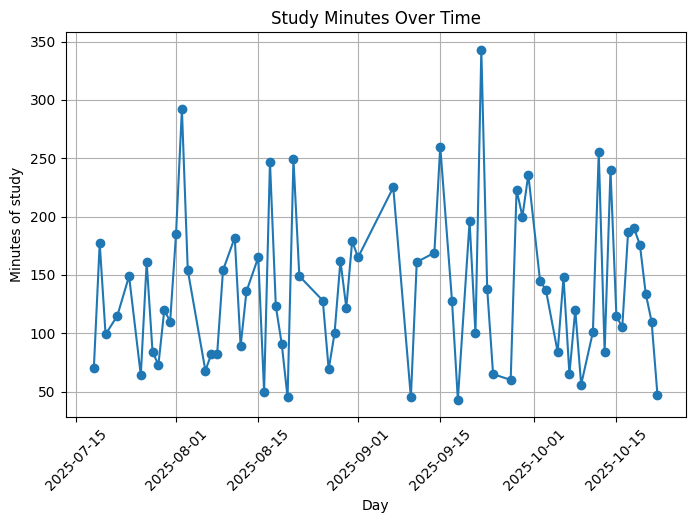

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(df['DAY'], df['minutes'], marker='o')
plt.xlabel('Day')
plt.ylabel('Minutes of study')
plt.title('Study Minutes Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Growth rate

In [8]:
df['growth_rate (%)'] = (
    df['minutes']
    .replace(0, pd.NA)     # Treat 0 as missing
    .pct_change() * 100
)

df['growth_rate (%)'] = df['growth_rate (%)'].replace([np.inf, -np.inf], pd.NA).fillna(0)

print(df[['growth_rate (%)']].round(2))

    growth_rate (%)
0              0.00
1            152.86
2            -44.07
3             16.16
4             29.57
..              ...
66             1.60
67            -7.37
68           -23.86
69           -17.91
70           -57.27

[71 rows x 1 columns]


### Linear regression

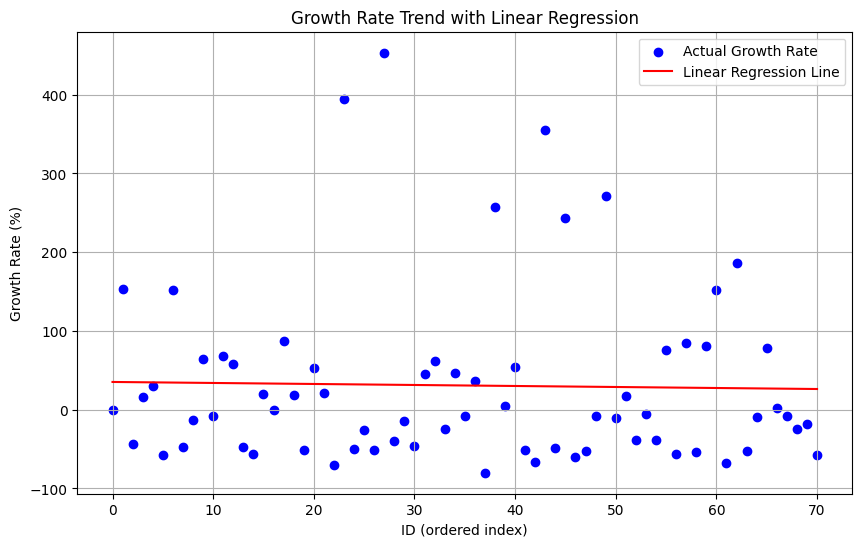

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df['id'] = np.arange(len(df))

# Prepare data for linear regression
X = df[['id']]
y = df['growth_rate (%)']

model = LinearRegression()
model.fit(X, y)

# Predict values
df['predicted_growth'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(df['id'], df['growth_rate (%)'], color='blue', label='Actual Growth Rate')
plt.plot(df['id'], df['predicted_growth'], color='red', label='Linear Regression Line')

plt.xlabel('ID (ordered index)')
plt.ylabel('Growth Rate (%)')
plt.title('Growth Rate Trend with Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### Others

In [10]:
valid_minutes = df['minutes'].replace(0, pd.NA).dropna()

if not valid_minutes.empty:
    initial = valid_minutes.iloc[0]
    final = valid_minutes.iloc[-1]
    overall_growth = ((final - initial) / initial) * 100
    print(f"Overall growth rate from start to end: {overall_growth:.2f}%")
else:
    print("Not enough valid data to calculate growth.")

Overall growth rate from start to end: -32.86%


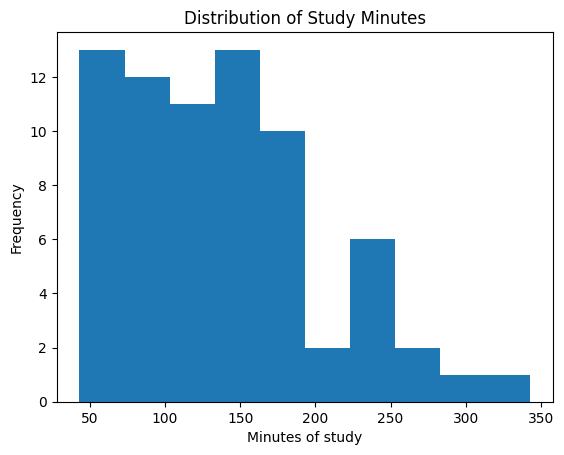

In [11]:
df['minutes'].plot.hist()
plt.xlabel("Minutes of study")
plt.title("Distribution of Study Minutes")
plt.show()